# Mini Project Notebook: Customer segmentation using clustering

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

## Learning Objectives

At the end of the experiment, you will be able to :

* extract summary level insight from a given customer dataset.

* handle the missing data and identify the underlying pattern or structure of the data.

* create an unsupervised model that generates the optimum number of segments for the customer base

* identify customer segments based on the overall buying behaviour


## Dataset

The dataset chosen for this mini project is the Online Retail dataset. It is a transnational data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

The dataset contains 541909 records, and each record is made up of 8 fields.

To know more about the dataset : [click here](https://archive.ics.uci.edu/ml/datasets/Online+Retail)

## Information

**Clustering** is the task of grouping together a set of objects so that the objects in the same cluster are more similar to each other than to objects in other clusters. Similarity is a measure that reflects the strength of the relationship between two data objects.

In the clustering calculation, K-Means is a very popular algorithm. In this analysis, this method is used to cluster the similar data items.

In Retail and E-Commerce (B2C), and more broadly in B2B, one of the key elements shaping the business strategy of a firm is understanding of customer behaviour. More specifically, understanding the customers based on different business metrics: how much they spend (revenue), how often they spend (frequency), are they new or existing customers, what are their favorite products, etc... Such understanding in turn helps direct marketing, sales, account management and product teams to support customers on a personalized level and improve the product offering.

Furthermore, segmenting customers into different categories based on similar/cyclical buying pattern over a period of 1 year helps the retail shops manage their inventory better, thereby lowering costs and raising revenues by placing the orders in sync with the buying cycles.

## Problem Statement

Perform customer segmentation for an Online Retail using an Unsupervised Clustering technique

### Import Required packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# YOUR CODE HERE
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



## Data Wrangling

## Load the data

In [ ]:
# YOUR CODE HERE
# Use read_excel for .xlsx files instead of read_csv
df = pd.read_excel("/content/drive/MyDrive/M5project/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Pre-processing

Explore the dataset by performing the following operations:

* There is a lot of redundant data. Identify such data and take appropriate action.

  **Hint:** refer to this [link](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html)

* Most Invoices appear as normal transactions with positive quantity and prices, but there are some prefixed with "C" or "A" which denote different transaction types. Invoice starting with C represents cancelled order and A represents the Adjusted. Identify such data and take appropriate action.

  **Hint:** Check the negative values in Quantity column for all cancelled orders

* Handle the null values by dropping or filling with appropriate mean


* Some of the transactions based on the `StockCode` variable are not actually products, but representing the costs or fees regarding to the post or bank or other tansactions. Find such data and handle it accordingly.

  Hint:
    - The transaction with `'POST' 'PADS' 'M' 'DOT' 'C2' 'BANK CHARGES'` as their `StockCodes` are considered as irrelevant transactions.

* Identify the outliers in the UntiPrice and Quantity and handle them accordingly.

  **Hint:** [link](https://kanoki.org/2020/04/23/how-to-remove-outliers-in-python/)

* Create a DayOfWeek column using `InvoiceDate`, Hint: pd.to_datetime()

**Note:** Perform all the above operations using a function to reuse and apply the same for test data.

In [ ]:
# YOUR CODE HERE
def preprocess_data(df):
    df = df.drop_duplicates()
    df = df[~df['InvoiceNo'].astype(str).str.startswith(('C','A'))]
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    df = df.dropna()
    df = df[~df['StockCode'].isin(['POST','PADS','M','DOT','C2','BANK CHARGES'])]
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
    return df


## Understanding new insights from the data

1.  Are there any free items in the data? How many are there?

2.  Find the number of transactions per country and visualize using an appropriate plot

3.  What is the ratio of customers who are repeat purchasers vs single-time purchasers? Visualize using an appropriate plot.

4. Plot heatmap showing unit price per month and day of the week

  **Hint:** Month name as index on Y-axis, Day of the week on X-axis

5. Find the top 10 customers who bought the most no.of items. Also find the top 10 Items bought by most no.of customers.

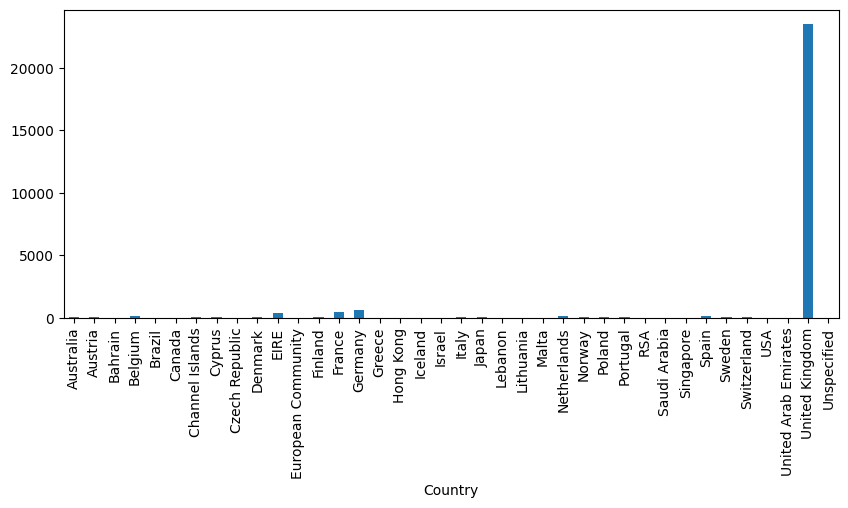

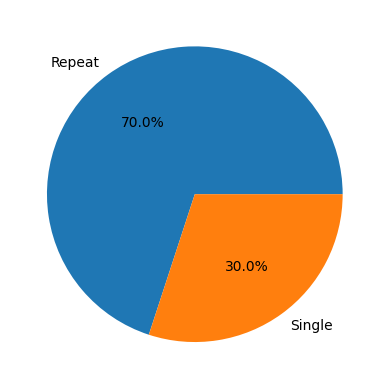

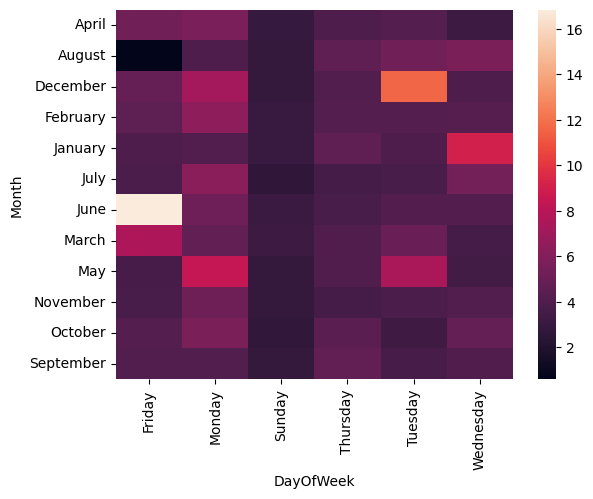

,CustomerID
Description,
REGENCY CAKESTAND 3 TIER,887
WHITE HANGING HEART T-LIGHT HOLDER,858
PARTY BUNTING,708
ASSORTED COLOUR BIRD ORNAMENT,679
SET OF 3 CAKE TINS PANTRY DESIGN,640
PACK OF 72 RETROSPOT CAKE CASES,636
JUMBO BAG RED RETROSPOT,636
PAPER CHAIN KIT 50'S CHRISTMAS,615
NATURAL SLATE HEART CHALKBOARD,590


In [ ]:
# YOUR CODE HERE
# 1. Free items
free_items = df[df['UnitPrice'] == 0]
free_items.shape[0]

# 2. Transactions per country
df.groupby('Country')['InvoiceNo'].nunique().plot(kind='bar', figsize=(10,4))
plt.show()

# 3. Repeat vs single-time customers
cust_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat = cust_freq[cust_freq > 1].count()
single = cust_freq[cust_freq == 1].count()

plt.pie([repeat, single], labels=['Repeat', 'Single'], autopct='%1.1f%%')
plt.show()

# 4. Heatmap
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month_name()
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

pivot = df.pivot_table(values='UnitPrice', index='Month', columns='DayOfWeek', aggfunc='mean')
sns.heatmap(pivot)
plt.show()

# 5. Top customers & items
df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)
df.groupby('Description')['CustomerID'].nunique().sort_values(ascending=False).head(10)


## Feature Engineering and Transformation

### Create new features to uncover better insights and drop the unwanted columns

* Create a new column which represents Total amount spent by each customer

    **Hint:** Quantity * UnitPrice

* Customer IDs are seen to be repeated. Maintain unique customer IDs by grouping and summing up all possible observations per customer.

    **Hint:** [pandas.groupby.agg](https://pandas.pydata.org/pandas-docs/version/0.22/generated/pandas.core.groupby.DataFrameGroupBy.agg.html)

**Note:** Perform the above operations in function, to reuse and apply the same for test data

In [ ]:
# YOUR CODE HERE
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo':'nunique',
    'Quantity':'sum',
    'TotalAmount':'sum'
}).reset_index()

customer_df.columns = ['CustomerID','Frequency','TotalItems','TotalSpent']


### Scale the data

Apply `StandardScaler` on the features.

In [ ]:
# YOUR CODE HERE for scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_df[['Frequency','TotalItems','TotalSpent']])


## Clustering

### Apply k-means algorithm to identify a specific number of clusters


* Fit the k-means model

* Extract and store the cluster centroids

Below are the parameters for k-means, which are helpful

**n_clusters** is no. of clusters specified

**k-means++** is a random initialization method for centroids to avoid random initialisation trap

**max_iter** is max no of iterations defined when k-means is running

**n_init** is no. of times k-means will run with different initial centroids

[why-is-k-means-slower-than-random-initialization-k-means](https://stats.stackexchange.com/questions/185396/why-is-k-means-slower-than-random-initialization-k-means/185422)

In [ ]:
# YOUR CODE HERE to apply KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(scaled_data)


#### Find the optimal number of clusters (K) by using the [Elbow method](https://pythonprogramminglanguage.com/kmeans-elbow-method/).

Use the optimal no. of clusters and store the cluster centroids

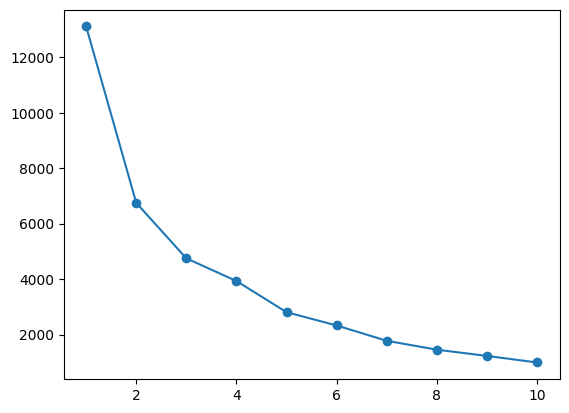

In [ ]:
# YOUR CODE HERE
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.show()


### Report Analysis

- Discuss the pros and cons of removing the missing values vs replacing with the mean values
- Based on the visualization of clusters, comment on the difference in buying patterns of each cluster
- What other methods could be used to determine the optimal no. of clusters?

# Type your answers here

1. Pros and cons of removing missing values vs replacing with mean

Removing missing values helps maintain data accuracy and avoids introducing artificial values, but it can reduce the dataset size and may lead to loss of useful information.
Replacing missing values with the mean keeps all records in the dataset, but it can distort the original data distribution and reduce variability.

2. Difference in buying patterns of each cluster

The clusters show clear differences in customer behavior. One cluster represents high-value customers who purchase frequently and spend more. Another cluster consists of moderate buyers with average spending and purchase frequency. The remaining clusters represent low-frequency and low-spending customers who purchase occasionally.

3. Other methods to find the optimal number of clusters

Other methods include the Silhouette Score, Davies-Bouldin Index, and the Gap Statistic. These methods evaluate cluster quality and separation to help determine the optimal number of clusters.